In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
file_path = 'archive/Loan_approval_data_2025.csv'
data = pd.read_csv(file_path)
data.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


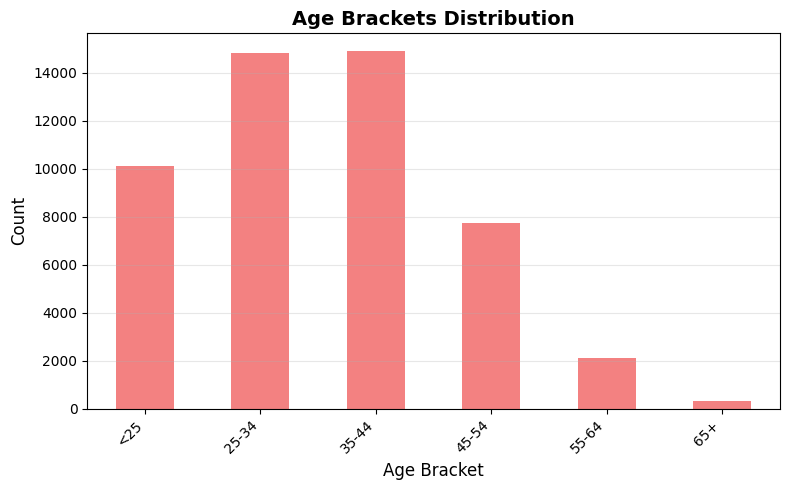

In [39]:
# Histogram for Age Brackets
plt.figure(figsize=(8, 5))
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
age_brackets = pd.cut(data['age'], bins=age_bins, labels=age_labels, right=False)
age_brackets.value_counts().sort_index().plot(kind='bar', color='#F38181')
plt.title('Age Brackets Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age Bracket', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

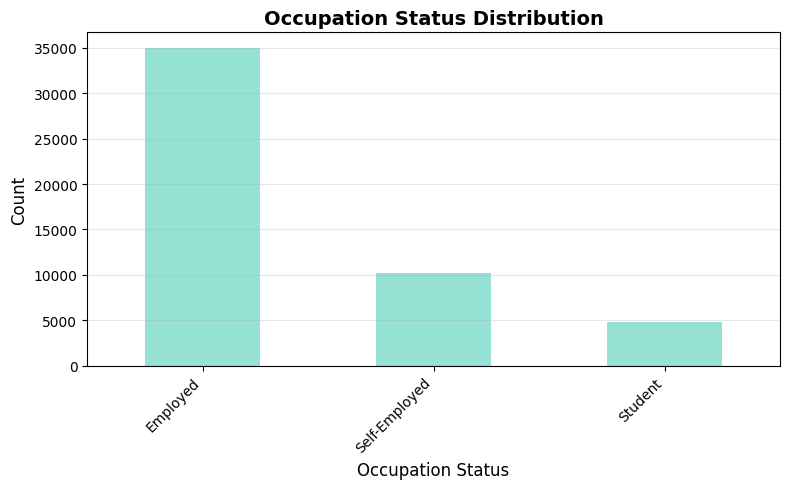

In [40]:
# Histogram for Occupation Status
plt.figure(figsize=(8, 5))
data['occupation_status'].value_counts().plot(kind='bar', color='#95E1D3')
plt.title('Occupation Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Occupation Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

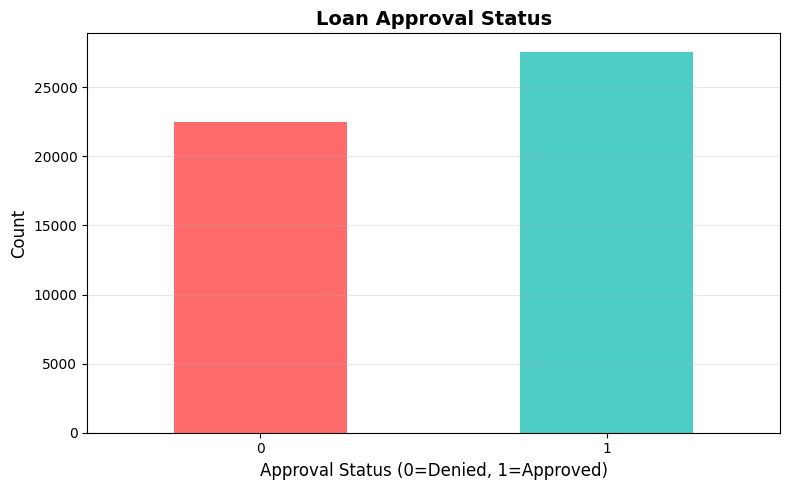

In [41]:
# Histogram for Loan Approval Status
plt.figure(figsize=(8, 5))
data['loan_status'].value_counts().sort_index().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Loan Approval Status', fontsize=14, fontweight='bold')
plt.xlabel('Approval Status (0=Denied, 1=Approved)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Multiple Linear Regression Analysis

Regression model to investigate how predictors affect loan approval chances.

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from itertools import combinations

# Check data structure and types
print("Data shape:", data.shape)
print("\nData types and missing values:")
print(data.info())
print("\nFirst few rows:")
print(data.head())
print("\nBasic statistics:")
print(data.describe())

Data shape: (50000, 20)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent         

In [43]:
# Prepare data for regression
df = data.copy()

all_categorical = df.select_dtypes(include=['object']).columns.tolist()
exclude_cols = ['customer_id']
categorical_cols = [c for c in all_categorical if c not in exclude_cols and df[c].nunique() <= 50]
print(f"Categorical columns to encode (excluded ids/high-cardinality): {categorical_cols}")

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"\n{col} encoding:")
    classes = list(le.classes_)
    for i, label in enumerate(classes[:20]):
        print(f"  {label} = {i}")
    if len(classes) > 20:
        print(f"  ... and {len(classes) - 20} more classes (truncated)")

feature_cols = [col for col in df.columns if col not in all_categorical + ['loan_status']]
print(f"\nFeature columns for regression: {feature_cols}")

Categorical columns to encode (excluded ids/high-cardinality): ['occupation_status', 'product_type', 'loan_intent']

occupation_status encoding:
  Employed = 0
  Self-Employed = 1
  Student = 2

product_type encoding:
  Credit Card = 0
  Line of Credit = 1
  Personal Loan = 2

loan_intent encoding:
  Business = 0
  Debt Consolidation = 1
  Education = 2
  Home Improvement = 3
  Medical = 4
  Personal = 5

Feature columns for regression: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_encoded', 'product_type_encoded', 'loan_intent_encoded']

product_type encoding:
  Credit Card = 0
  Line of Credit = 1
  Personal Loan = 2

loan_intent encoding:
  Business = 0
  Debt Consolidation = 1
  Education = 2
  Home Improvement = 3
  Medic

In [44]:
X = df[feature_cols]
y = df['loan_status']

X_with_const = sm.add_constant(X)

full_model = sm.OLS(y, X_with_const).fit()

print("="*70)
print("FULL MODEL (All Predictors)")
print("="*70)
print(full_model.summary())

print(f"\nFull Model - AIC: {full_model.aic:.2f}, BIC: {full_model.bic:.2f}")

FULL MODEL (All Predictors)
                            OLS Regression Results                            
Dep. Variable:            loan_status   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     2618.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:21:52   Log-Likelihood:                -19428.
No. Observations:               50000   AIC:                         3.889e+04
Df Residuals:                   49981   BIC:                         3.906e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [45]:
# Model selection using backward elimination with AIC
current_features = feature_cols.copy()
model_history = []

print("\n" + "="*70)
print("BACKWARD ELIMINATION USING AIC")
print("="*70)

while len(current_features) > 1:
    X_current = df[current_features]
    X_current_const = sm.add_constant(X_current)
    current_model = sm.OLS(y, X_current_const).fit()
    
    model_history.append({
        'features': current_features.copy(),
        'n_features': len(current_features),
        'aic': current_model.aic,
        'bic': current_model.bic,
        'r_squared': current_model.rsquared,
        'adj_r_squared': current_model.rsquared_adj
    })
    
    print(f"\nModel with {len(current_features)} features - AIC: {current_model.aic:.2f}, BIC: {current_model.bic:.2f}")
    print(f"Features: {current_features}")
    
    pvalues = current_model.pvalues[1:]
    max_pvalue_feature = pvalues.idxmax()
    max_pvalue = pvalues.max()
    
    if max_pvalue > 0.05:
        print(f"Removing: {max_pvalue_feature} (p-value: {max_pvalue:.4f})")
        current_features.remove(max_pvalue_feature)
    else:
        print("All remaining features are significant (p < 0.05)")
        break

model_comparison = pd.DataFrame(model_history)
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(model_comparison.to_string())


BACKWARD ELIMINATION USING AIC

Model with 18 features - AIC: 38894.05, BIC: 39061.62
Features: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_encoded', 'product_type_encoded', 'loan_intent_encoded']
Removing: loan_to_income_ratio (p-value: 0.6856)

Model with 17 features - AIC: 38892.21, BIC: 39050.97
Features: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_encoded', 'product_type_encoded', 'loan_intent_encoded']
Removing: interest_rate (p-value: 0.1443)

Model with 16 features - AIC: 38892.


BEST MODEL (Lowest AIC: 38892.21)
Features selected: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_encoded', 'product_type_encoded', 'loan_intent_encoded']


                            OLS Regression Results                            
Dep. Variable:            loan_status   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     2772.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:21:52   Log-Likelihood:                -19428.
No. Observations:               50000   AIC:                         3.889e+04
Df Residuals:                   49982   BIC:    

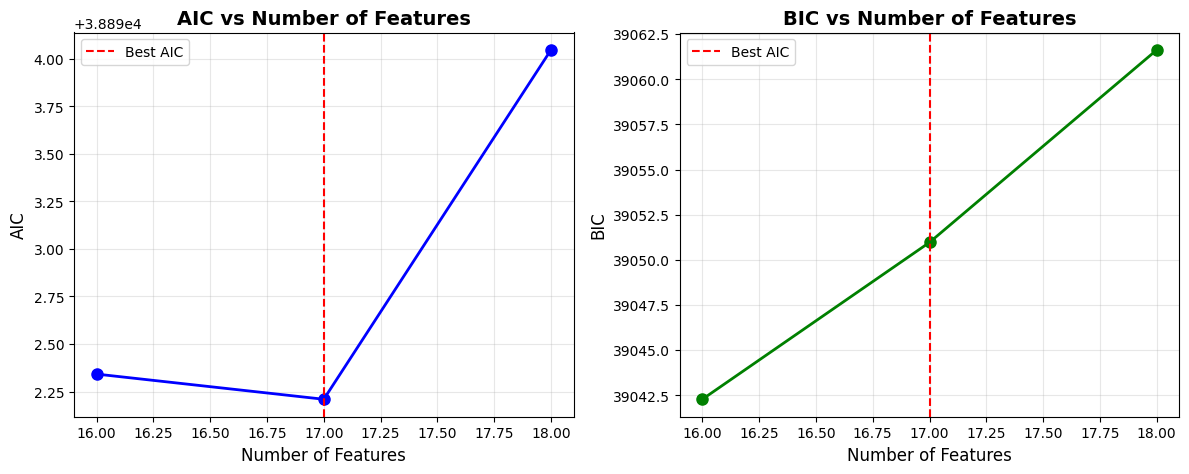

In [46]:
# Fit best model (lowest AIC)
best_idx = model_comparison['aic'].idxmin()
best_features = model_comparison.loc[best_idx, 'features']

X_best = df[best_features]
X_best_const = sm.add_constant(X_best)
best_model = sm.OLS(y, X_best_const).fit()

print("\n" + "="*70)
print(f"BEST MODEL (Lowest AIC: {best_model.aic:.2f})")
print("="*70)
print(f"Features selected: {best_features}")
print("\n")
print(best_model.summary())

# Create visualization of AIC/BIC across models
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_comparison['n_features'], model_comparison['aic'], 'bo-', linewidth=2, markersize=8)
plt.axvline(x=model_comparison.loc[best_idx, 'n_features'], color='r', linestyle='--', label='Best AIC')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('AIC', fontsize=12)
plt.title('AIC vs Number of Features', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_comparison['n_features'], model_comparison['bic'], 'go-', linewidth=2, markersize=8)
plt.axvline(x=model_comparison.loc[best_idx, 'n_features'], color='r', linestyle='--', label='Best AIC')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('BIC', fontsize=12)
plt.title('BIC vs Number of Features', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
# Interpretation of coefficients
print("\n" + "="*70)
print("INTERPRETATION OF RESULTS")
print("="*70)

coefficients = best_model.params[1:]  # Skip intercept
pvalues = best_model.pvalues[1:]

interpretation_df = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'P-value': pvalues.values,
    'Significant': ['Yes' if p < 0.05 else 'No' for p in pvalues.values]
})

print("\nCoefficients and Significance:")
print(interpretation_df.to_string(index=False))

print("\n" + "-"*70)
print("CONCLUSIONS:")
print("-"*70)
print(f"\nIntercept: {best_model.params[0]:.4f}")
print(f"\nR-squared: {best_model.rsquared:.4f} (Model explains {best_model.rsquared*100:.2f}% of variance)")
print(f"Adjusted R-squared: {best_model.rsquared_adj:.4f}")

print("\nPositive coefficients → INCREASE chances of loan approval")
print("Negative coefficients → DECREASE chances of loan approval")

print("\nSignificant predictors (p < 0.05):")
for idx, row in interpretation_df.iterrows():
    if row['Significant'] == 'Yes':
        direction = "increases" if row['Coefficient'] > 0 else "decreases"
        print(f"  • {row['Feature']}: {direction} approval chances (coef: {row['Coefficient']:.4f}, p: {row['P-value']:.4f})")


INTERPRETATION OF RESULTS

Coefficients and Significance:
                  Feature   Coefficient       P-value Significant
                      age  8.528309e-04  2.197021e-04         Yes
           years_employed  3.294973e-03  1.521097e-30         Yes
            annual_income  2.454974e-07  4.466549e-02         Yes
             credit_score  2.650338e-03  0.000000e+00         Yes
     credit_history_years  9.010625e-03 3.027432e-206         Yes
           savings_assets  3.478458e-07  6.049484e-03         Yes
             current_debt -1.965259e-06  2.607977e-10         Yes
         defaults_on_file -3.064037e-01  0.000000e+00         Yes
  delinquencies_last_2yrs -9.610673e-02  0.000000e+00         Yes
         derogatory_marks -1.125301e-01 3.133514e-171         Yes
              loan_amount  1.125996e-06  1.288831e-15         Yes
            interest_rate  1.107669e-03  1.443009e-01          No
     debt_to_income_ratio -8.866591e-01  0.000000e+00         Yes
  payment_to_inco

C:\Users\noahp\AppData\Local\Temp\ipykernel_32060\3235727348.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nIntercept: {best_model.params[0]:.4f}")


In [48]:
# Train a logistic regression on the selected best features and add a prediction helper
from sklearn.linear_model import LogisticRegression

best_features = list(best_features) if not isinstance(best_features, list) else best_features

X_logit = df[best_features]
y_logit = df['loan_status']

logit_model = LogisticRegression(solver='liblinear', max_iter=1000)
logit_model.fit(X_logit, y_logit)
print("Trained logistic regression on selected features:", best_features)


def predict_approval(user_input: dict) -> float:
    """Predict percent chance of loan approval.

    Parameters
    - user_input: dict mapping feature names to values. For features that are categorical
      in the original data you should provide the original category string under the
      original column name (e.g., 'occupation_status': 'Employed').

    Returns
    - probability percent (0.0 - 100.0)
    """
    x = []
    for feat in best_features:
        if feat.endswith('_encoded'):
            orig_col = feat[:-8]
            if orig_col not in le_dict:
                raise ValueError(f"Encoder for '{orig_col}' not found in notebook environment.")
            if orig_col not in user_input:
                raise ValueError(f"Missing required field: '{orig_col}' for feature '{feat}'.")
            raw_val = user_input[orig_col]
            le = le_dict[orig_col]
            
            try:
                enc_val = le.transform([raw_val])[0]
            except ValueError:
                allowed = list(le.classes_)
                raise ValueError(f"Value '{raw_val}' for '{orig_col}' was not seen during training. Allowed values: {allowed}")
            x.append(float(enc_val))
        else:
            if feat not in user_input:
                raise ValueError(f"Missing required numeric field: '{feat}'.")
            x.append(float(user_input[feat]))

    prob = logit_model.predict_proba([x])[0, 1]
    return float(prob * 100.0)

sample_input = {}
for feat in best_features:
    if feat.endswith('_encoded'):
        orig = feat[:-8]
        sample_input[orig] = le_dict[orig].classes_[0]
    else:
        sample_input[feat] = float(df[feat].median())

print("Sample input used for quick test:", sample_input)
print(f"Sample predicted approval chance: {predict_approval(sample_input):.2f}%")


Trained logistic regression on selected features: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_encoded', 'product_type_encoded', 'loan_intent_encoded']
Sample input used for quick test: {'age': 35.0, 'years_employed': 4.9, 'annual_income': 41607.5, 'credit_score': 643.0, 'credit_history_years': 6.1, 'savings_assets': 568.0, 'current_debt': 10385.0, 'defaults_on_file': 0.0, 'delinquencies_last_2yrs': 0.0, 'derogatory_marks': 0.0, 'loan_amount': 26100.0, 'interest_rate': 15.44, 'debt_to_income_ratio': 0.265, 'payment_to_income_ratio': 0.207, 'occupation_status': 'Employed', 'product_type': 'Credit Card', 'loan_intent': 'Business'}
Sample predicted approval chance: 58.88%


c:\Users\noahp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [49]:
print("Features required by the model:", best_features)

result = predict_approval({
  'age': 34,
  'years_employed': 5,
  'annual_income': 50000,
  'credit_score': 680,
  'credit_history_years': 6,
  'savings_assets': 1000,
  'current_debt': 15000,
  'defaults_on_file': 0,
  'delinquencies_last_2yrs': 0,
  'derogatory_marks': 0,
  'loan_amount': 20000,
  'interest_rate': 12.5,
  'debt_to_income_ratio': 0.25,
  'payment_to_income_ratio': 0.15,
  'occupation_status': 'Employed',
  'product_type': 'Credit Card',
  'loan_intent': 'Business'
})
print(f"Predicted approval chance: {result:.2f}%")

Features required by the model: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_encoded', 'product_type_encoded', 'loan_intent_encoded']
Predicted approval chance: 73.82%


c:\Users\noahp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
